# CRM Acess Governance & Customer Data PRotection
## Exploratory Data Analysis (EDA) - V.2

Este notebook é a etapa exploratória do projeto, onde podemos entender a base de dados

A base de dados é pública e pode ser adquirida no link: https://www.kaggle.com/datasets/dataset066/permission-aware-crm-governance-synthetic-dataset

Representa eventis de acesso a um ambiente de CRM e contém informações sobre perfil do usuário, ação realizada, dispositivo, horario, senbilidade do dado, permissões, comportamento de login, scores de risco/governança e decisão final de acesso.

## Objetivos do EAD

1. Validar estrutura e qualidade dos dados.
2. Entender a distribuição das variáveis numéricas e categóricas.
3. Analisar comportamento de acesso e fatores de risco.
4. Investigar relações entre `Permission_Granted` e `Access_Decision`.
5. Identificar fatores associados a bloqueios e revisões.
6. Explorar interações entre perfil, ação, dispositivo, sensibilidade e comportamento.
7. Detectar valores extremos e padrões incomuns.
8. Gerar hipóteses para a futura política de governança.
9. Preparar métricas e dimensões úteis para o modelo analítico e Power BI.

In [1]:
# Importação de bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = Path("Permission_Aware_CRM_Governance_Synthetic_50000.csv")

## 2. Carregamento e Data Discovery

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]:,}")
print(df.head())

Linhas: 50,000
Colunas: 15
   User_ID       Role Region Lead_Source CRM_Action  Daily_Logins  \
0        1      Admin  North    Referral   ViewLead             6   
1        2  Sales Rep   West         Web   ViewLead             5   
2        3  Sales Rep  South     Partner   EditLead             6   
3        4    Analyst  South    Campaign   ViewLead            10   
4        5  Sales Rep   West         Web   EditLead             6   

   Failed_Logins  Access_Hour Device_Type  Data_Sensitivity  \
0              1           10     Managed                 5   
1              1           12     Managed                 5   
2              1           20     Managed                 1   
3              0           10     Managed                 3   
4              2           17     Managed                 1   

   Policy_Compliance_Score  Anomaly_Score  Permission_Granted  \
0                    76.19           0.11                True   
1                    62.87           0.46        

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User_ID                  50000 non-null  int64  
 1   Role                     50000 non-null  str    
 2   Region                   50000 non-null  str    
 3   Lead_Source              50000 non-null  str    
 4   CRM_Action               50000 non-null  str    
 5   Daily_Logins             50000 non-null  int64  
 6   Failed_Logins            50000 non-null  int64  
 7   Access_Hour              50000 non-null  int64  
 8   Device_Type              50000 non-null  str    
 9   Data_Sensitivity         50000 non-null  int64  
 10  Policy_Compliance_Score  50000 non-null  float64
 11  Anomaly_Score            50000 non-null  float64
 12  Permission_Granted       50000 non-null  bool   
 13  Governance_Score         50000 non-null  float64
 14  Access_Decision          50000 no

In [4]:
structural_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "Non_Null": df.notna().sum(),
    "nulls": df.isna().sum(),
    "Null_%": (df.isna().mean() * 100).round(2),
    "Unique_values": df.nunique(),
    "Cardinality_%": (df.nunique() / len(df) * 100).round(2) 
})

display(structural_summary)

,data_type,Non_Null,nulls,Null_%,Unique_values,Cardinality_%
User_ID,int64,50000,0,0.00,50000,100.00
Role,str,50000,0,0.00,5,0.01
Region,str,50000,0,0.00,4,0.01
Lead_Source,str,50000,0,0.00,5,0.01
CRM_Action,str,50000,0,0.00,6,0.01
Daily_Logins,int64,50000,0,0.00,21,0.04
Failed_Logins,int64,50000,0,0.00,7,0.01
Access_Hour,int64,50000,0,0.00,17,0.03
Device_Type,str,50000,0,0.00,2,0.00
Data_Sensitivity,int64,50000,0,0.00,5,0.01


In [5]:


low_cardinality_cols = [
    col for col in df.columns
    if df[col].nunique() <= 20
]

for col in low_cardinality_cols:
    print(f"\n{col} ({df[col].nunique()} valores únicos)")
    print(df[col].unique())



Role (5 valores únicos)
<StringArray>
['Admin', 'Sales Rep', 'Analyst', 'Support', 'Manager']
Length: 5, dtype: str

Region (4 valores únicos)
<StringArray>
['North', 'West', 'South', 'East']
Length: 4, dtype: str

Lead_Source (5 valores únicos)
<StringArray>
['Referral', 'Web', 'Partner', 'Campaign', 'Email']
Length: 5, dtype: str

CRM_Action (6 valores únicos)
<StringArray>
[         'ViewLead',          'EditLead', 'CreateOpportunity',
         'ExportCRM',        'DeleteLead',   'ApproveDiscount']
Length: 6, dtype: str

Failed_Logins (7 valores únicos)
[1 0 2 4 3 5 6]

Access_Hour (17 valores únicos)
[10 12 20 17 15  8 18 14  7 16 13 22 11 19  9 21  6]

Device_Type (2 valores únicos)
<StringArray>
['Managed', 'BYOD']
Length: 2, dtype: str

Data_Sensitivity (5 valores únicos)
[5 1 3 2 4]

Permission_Granted (2 valores únicos)
[ True False]

Access_Decision (2 valores únicos)
<StringArray>
['Block', 'Review']
Length: 2, dtype: str


## 2.5 Dicionário inicial dos dados

| Campo | Interpretação | Categoria analítica |
|---|---|---|
| `User_ID` | Identificador do usuário | Identificador |
| `Role` | Perfil/função do usuário | Controle de acesso |
| `Region` | Região associada ao registro | Dimensão |
| `Lead_Source` | Origem comercial do lead | Dimensão |
| `CRM_Action` | Ação realizada/solicitada | Atividade |
| `Daily_Logins` | Quantidade de logins diários | Comportamento |
| `Failed_Logins` | Tentativas falhas | Segurança |
| `Access_Hour` | Hora do acesso | Contexto temporal |
| `Device_Type` | Tipo de dispositivo | Segurança |
| `Data_Sensitivity` | Nível de sensibilidade | Governança |
| `Policy_Compliance_Score` | Aderência às políticas | Governança |
| `Anomaly_Score` | Grau de comportamento anômalo | Segurança |
| `Permission_Granted` | Existência de permissão funcional | Autorização |
| `Governance_Score` | Score agregado de governança | Governança |
| `Access_Decision` | Resultado do acesso | Outcome |

Este dicionário será refinado mais adiante para uma **Data Classification Matrix**.

## Data Quality

In [6]:
missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2),
}).sort_values("Missing_Percentage", ascending=False)

display(missing)
print(f"Total de valores ausentes:{df.isna().sum().sum():,}")

,Missing_Count,Missing_Percentage
User_ID,0,0.00
Role,0,0.00
Region,0,0.00
Lead_Source,0,0.00
CRM_Action,0,0.00
Daily_Logins,0,0.00
Failed_Logins,0,0.00
Access_Hour,0,0.00
Device_Type,0,0.00
Data_Sensitivity,0,0.00


Total de valores ausentes:0


In [7]:
duplicate_count = df.duplicated().sum()
duplicate_pct = duplicate_count / len(df) * 100

print(f"Registros duplicados: {duplicate_count:,}")
print(f"Percentual duplicado: {duplicate_pct:.2f}%")


Registros duplicados: 0
Percentual duplicado: 0.00%


In [8]:
domain_checks = {
    "Access_Hour fora de 0-23": (~df["Access_Hour"].between(0, 23)).sum(),
    "Data_Sensitivity fora de 1-5": (~df["Data_Sensitivity"].between(1, 5)).sum(),
    "Anomaly_Score fora de 0-1": (~df["Anomaly_Score"].between(0, 1)).sum(),
    "Policy_Compliance_Score fora de 0-100": (~df["Policy_Compliance_Score"].between(0, 100)).sum(),
    "Governance_Score fora de 0-100": (~df["Governance_Score"].between(0, 100)).sum(),
    "Daily_Logins negativos": (df["Daily_Logins"] < 0).sum(),
    "Failed_Logins negativos": (df["Failed_Logins"] < 0).sum()
}

display(pd.Series(domain_checks, name="Invalid_Records").to_frame())

,Invalid_Records
Access_Hour fora de 0-23,0
Data_Sensitivity fora de 1-5,0
Anomaly_Score fora de 0-1,0
Policy_Compliance_Score fora de 0-100,0
Governance_Score fora de 0-100,0
Daily_Logins negativos,0
Failed_Logins negativos,0


## Descriptive Analysis

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.to_list()
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
User_ID,"50,000.00","25,000.50","14,433.90",1.00,"12,500.75","25,000.50","37,500.25","50,000.00"
Daily_Logins,"50,000.00",6.01,2.44,0.00,4.00,6.00,8.00,20.00
Failed_Logins,"50,000.00",0.50,0.71,0.00,0.00,0.00,1.00,6.00
Access_Hour,"50,000.00",14.03,4.91,6.00,10.00,14.00,18.00,22.00
Data_Sensitivity,"50,000.00",3.01,1.42,1.00,2.00,3.00,4.00,5.00
Policy_Compliance_Score,"50,000.00",81.86,9.69,41.74,75.17,82.00,88.80,100.00
Anomaly_Score,"50,000.00",0.22,0.12,0.00,0.12,0.20,0.29,0.87
Governance_Score,"50,000.00",51.05,6.82,23.95,46.36,51.63,56.12,68.71


In [10]:
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns.to_list()
display(df[categorical_cols].describe().T)

C:\Users\LeaoN\AppData\Local\Temp\ipykernel_14412\164963756.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "bool"]).columns.to_list()


,count,unique,top,freq
Role,50000,5,Sales Rep,20159
Region,50000,4,North,12577
Lead_Source,50000,5,Partner,10062
CRM_Action,50000,6,ViewLead,17696
Device_Type,50000,2,Managed,40035
Permission_Granted,50000,2,True,34069
Access_Decision,50000,2,Block,42072


## Variable Categories

In [11]:
for col in categorical_cols:
    frequency = (
        df[col]
        .value_counts(dropna=False)
        .to_frame("Count")
        .assign(Percentage=lambda x: (x["Count"] / len(df) * 100).round(2))
    )

    print(f"\n### {col}")
    display(frequency)


### Role


,Count,Percentage
Role,,
Sales Rep,20159,40.32
Manager,9904,19.81
Support,7566,15.13
Analyst,7389,14.78
Admin,4982,9.96



### Region


,Count,Percentage
Region,,
North,12577,25.15
South,12507,25.01
East,12466,24.93
West,12450,24.90



### Lead_Source


...

,Count,Percentage
Device_Type,,
Managed,40035,80.07
BYOD,9965,19.93



### Permission_Granted


,Count,Percentage
Permission_Granted,,
True,34069,68.14
False,15931,31.86



### Access_Decision


,Count,Percentage
Access_Decision,,
Block,42072,84.14
Review,7928,15.86


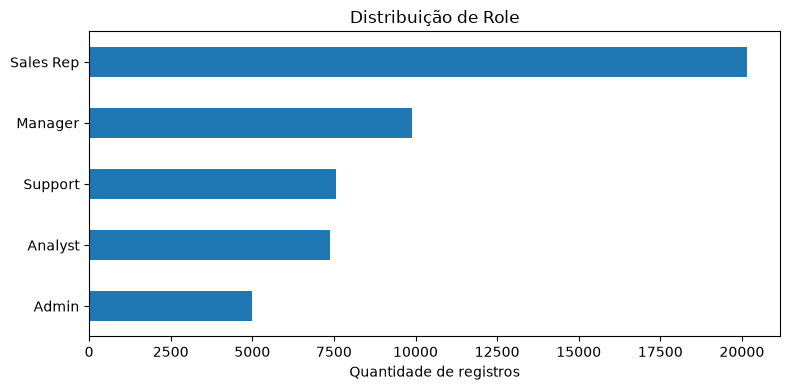

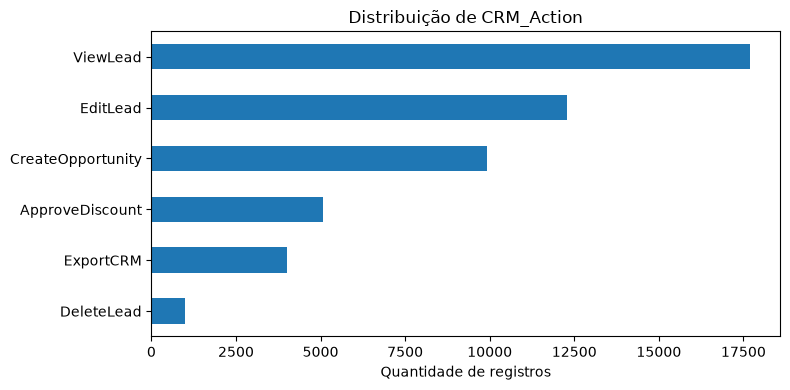

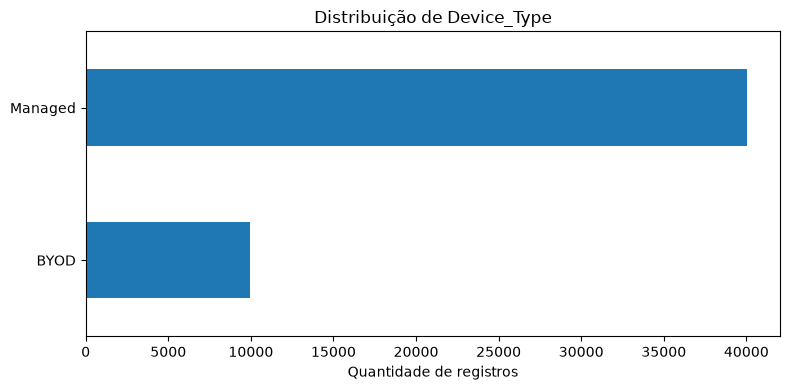

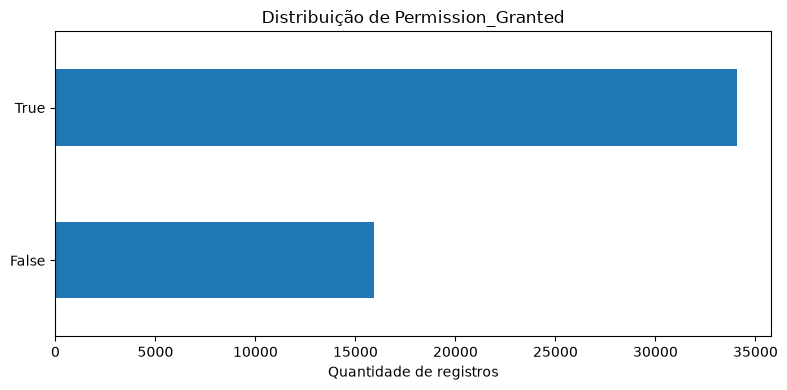

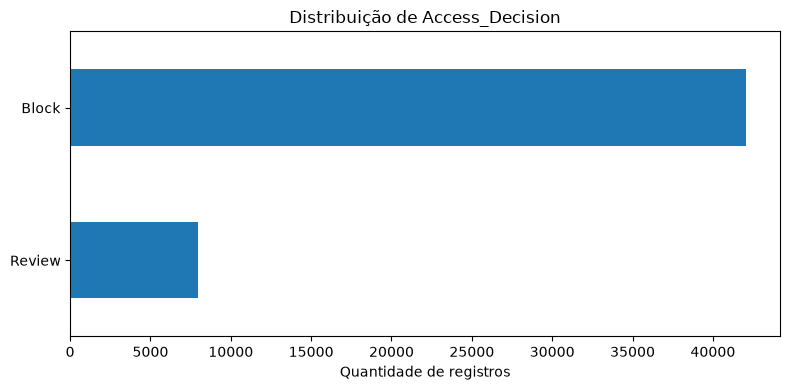

In [12]:
plot_cols = ["Role", "CRM_Action", "Device_Type", "Permission_Granted", "Access_Decision"]

for col in plot_cols:
    counts = df[col].value_counts().sort_values()
    ax = counts.plot(kind="barh", figsize=(8, 4))
    ax.set_title(f"Distribuição de {col}")
    ax.set_xlabel("Quantidade de registros")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## Univariate Analysis — Behavior, Security, and Governance

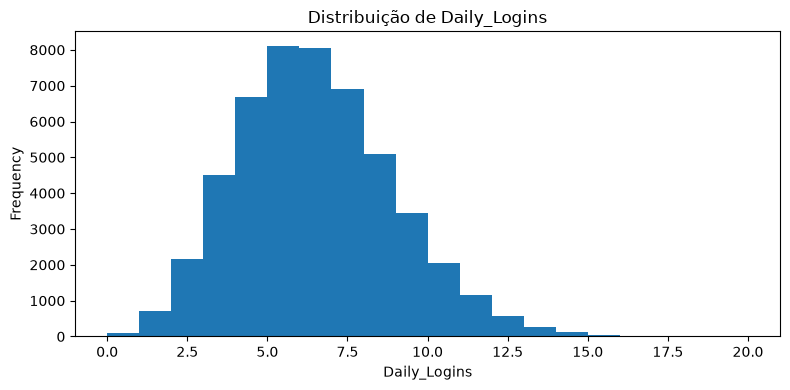

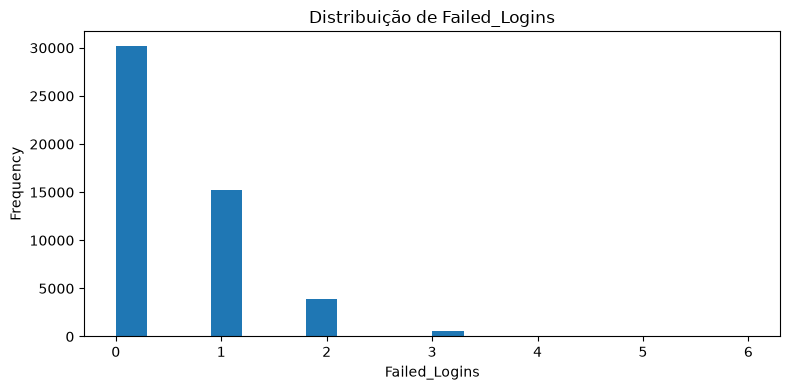

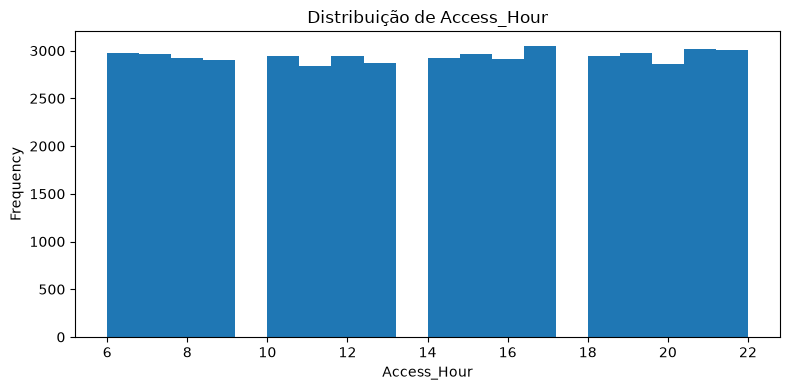

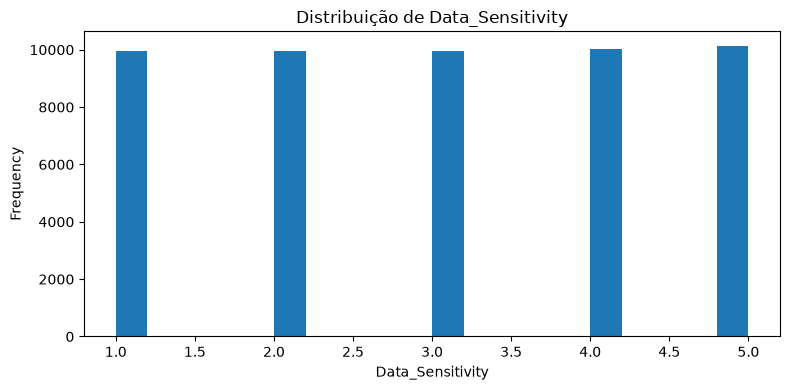

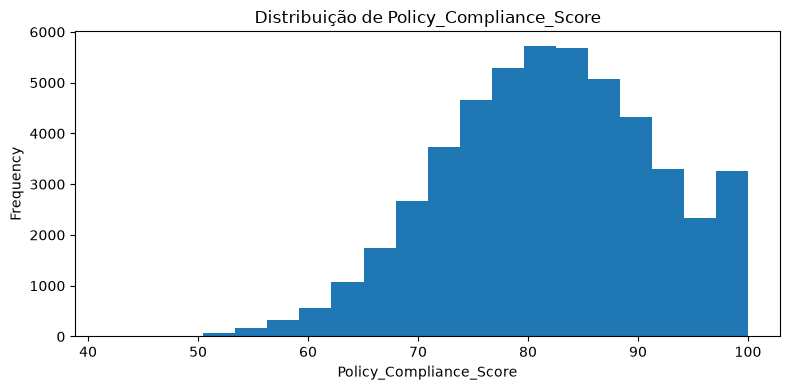

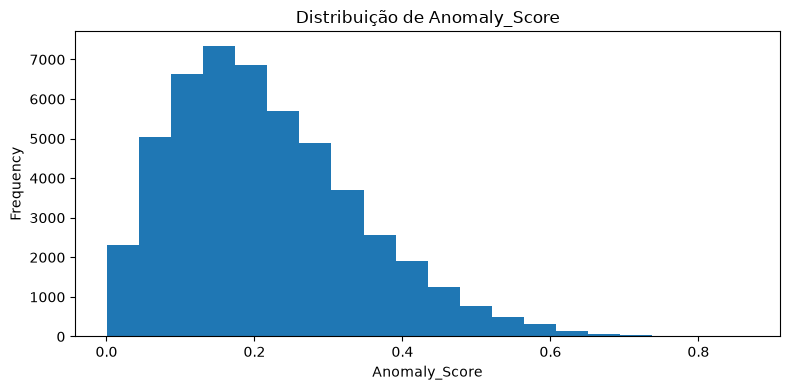

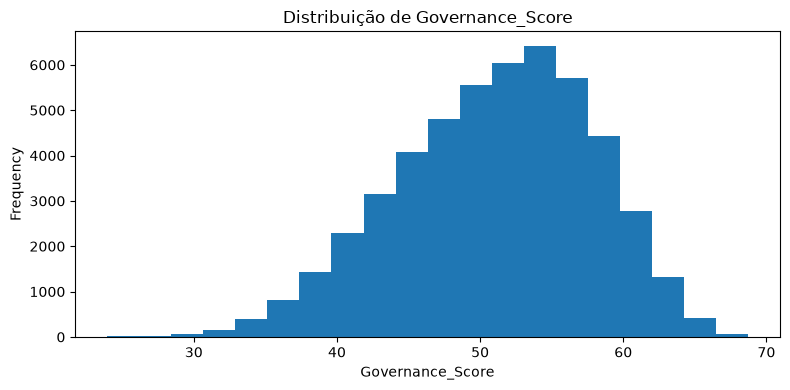

In [13]:
risk_numeric_cols = [
    "Daily_Logins",
    "Failed_Logins",
    "Access_Hour",
    "Data_Sensitivity",
    "Policy_Compliance_Score",
    "Anomaly_Score",
    "Governance_Score"
]

for col in risk_numeric_cols:
    ax = df[col].plot(kind="hist", bins=20, figsize=(8, 4))
    ax.set_title(f"Distribuição de {col}")
    ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()


## Outliers

C:\Users\LeaoN\AppData\Local\Temp\ipykernel_14412\3417142575.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)


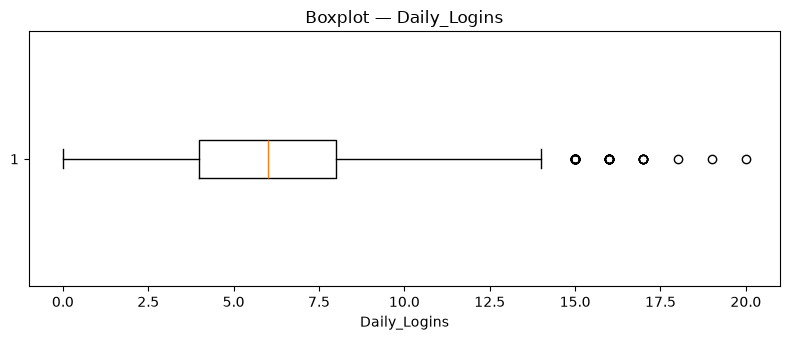

C:\Users\LeaoN\AppData\Local\Temp\ipykernel_14412\3417142575.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)


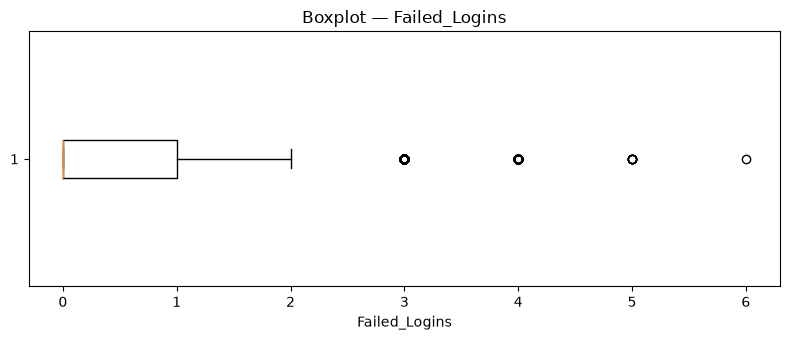

C:\Users\LeaoN\AppData\Local\Temp\ipykernel_14412\3417142575.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)


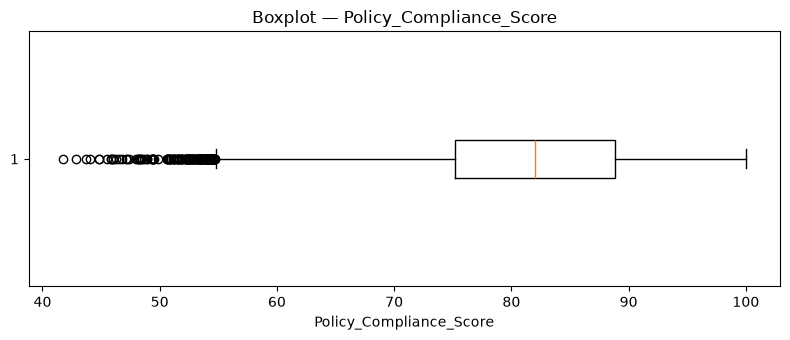

C:\Users\LeaoN\AppData\Local\Temp\ipykernel_14412\3417142575.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)


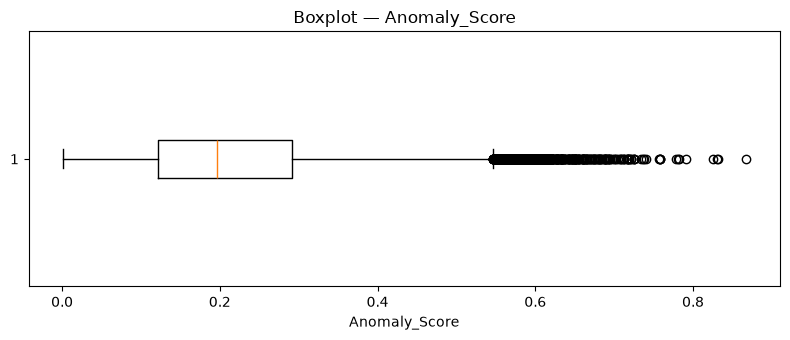

C:\Users\LeaoN\AppData\Local\Temp\ipykernel_14412\3417142575.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=False)


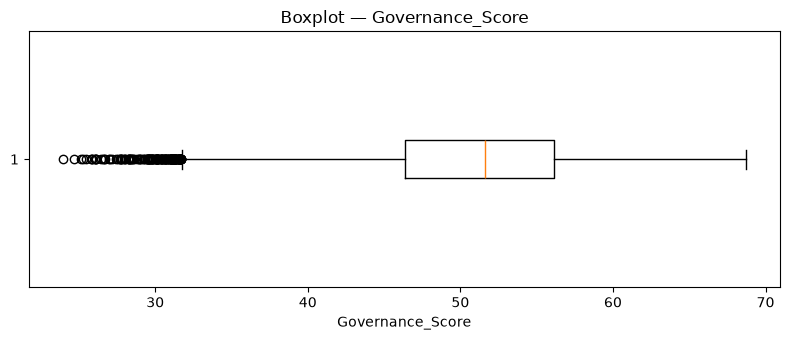

In [14]:
for col in [
    "Daily_Logins",
    "Failed_Logins",
    "Policy_Compliance_Score",
    "Anomaly_Score",
    "Governance_Score"
]:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.boxplot(df[col].dropna(), vert=False)
    ax.set_title(f"Boxplot — {col}")
    ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()


### IQR method
The IQR method is used to identify potentially unusual observations by defining lower and upper bounds based on the first and third quartiles. In this project, these observations are flagged for investigation rather than automatically removed, as extreme access behavior may represent relevant security events.

In [16]:
def iqr_summary(data, columns):
    rows = []

    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_count = ((data[col] < lower) | (data[col] > upper)).sum()

        rows.append({
            "Variable": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Potential_Outliers": outlier_count,
            "Outlier_%": outlier_count / len(data) * 100
        })

    return pd.DataFrame(rows)

display(
    iqr_summary(
        df,
        [
            "Daily_Logins",
            "Failed_Logins",
            "Policy_Compliance_Score",
            "Anomaly_Score",
            "Governance_Score"
        ]
    ).round(3)
)



,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Potential_Outliers,Outlier_%
0,Daily_Logins,4.00,8.00,4.00,-2.00,14.00,58,0.12
1,Failed_Logins,0.00,1.00,1.00,-1.50,2.50,706,1.41
2,Policy_Compliance_Score,75.17,88.80,13.63,54.73,109.25,160,0.32
3,Anomaly_Score,0.12,0.29,0.17,-0.13,0.55,692,1.38
4,Governance_Score,46.36,56.12,9.76,31.71,70.76,153,0.31


Study note — IQR method

The function above is not a built-in pandas function. It is a custom function created to summarize potential outliers using the Interquartile Range (IQR) method.

The main pandas method used inside it is:

Series.quantile()

which is used to calculate the first quartile (Q1 = 25%) and third quartile (Q3 = 75%).

The interquartile range is then calculated as:

IQR = Q3 - Q1

Potential outliers are identified using the commonly adopted limits:

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Values outside these limits are flagged as potential outliers. In this CRM governance project, however, they should not be automatically removed because unusual observations may represent relevant security events rather than data errors.

Further study:

Pandas documentation — quantile(): useful for understanding how Python calculates Q1, median, Q3 and other percentiles. 
NIST Engineering Statistics Handbook — Box Plot / Outliers: useful for understanding the statistical reasoning behind the 1.5 × IQR rule and its relationship with boxplots. - https://www.itl.nist.gov/div898/handbook/toolaids/pff/E-Handbook.pdf?utm_source=chatgpt.com 

## Access Decision - Variable of result

In [17]:
df_eda = df.copy()

df_eda["Is_Blocked"] = df_eda["Access_Decision"].eq("Block").astype(int)

decision_summary = (
    df_eda["Access_Decision"]
    .value_counts()
    .to_frame("Count")
    .assign(Percentage=lambda x: (x["Count"] / len(df_eda) * 100).round(2))
)

display(decision_summary)


,Count,Percentage
Access_Decision,,
Block,42072,84.14
Review,7928,15.86


## Permission Granted X Access Decision

In [18]:
permission_decision = pd.crosstab(
    df_eda["Permission_Granted"],
    df_eda["Access_Decision"],
    margins=True
)

permission_decision_pct = pd.crosstab(
    df_eda["Permission_Granted"],
    df_eda["Access_Decision"],
    normalize="index"
).mul(100).round(2)

display(permission_decision)
display(permission_decision_pct)

Access_Decision,Block,Review,All
Permission_Granted,,,
False,15929,2,15931
True,26143,7926,34069
All,42072,7928,50000


Access_Decision,Block,Review
Permission_Granted,,
False,99.99,0.01
True,76.74,23.26


## Block Rate by Dimension

In [19]:
def risk_group_summary(data, column):
    return (
        data.groupby(column)
        .agg(
            Records=("Is_Blocked", "size"),
            Block_Rate=("Is_Blocked", "mean"),
            Avg_Anomaly=("Anomaly_Score", "mean"),
            Avg_Compliance=("Policy_Compliance_Score", "mean"),
            Avg_Governance=("Governance_Score", "mean")
        )
        .assign(Block_Rate=lambda x: x["Block_Rate"] * 100)
        .sort_values("Block_Rate", ascending=False)
        .round(2)
    )

dimensions = [
    "Role",
    "Region",
    "Lead_Source",
    "CRM_Action",
    "Device_Type",
    "Data_Sensitivity",
    "Failed_Logins",
    "Permission_Granted"
]

for col in dimensions:
    print(f"\n### {col}")
    display(risk_group_summary(df_eda, col))


### Role


,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Role,,,,,
Analyst,7389,87.43,0.22,81.96,49.71
Support,7566,87.30,0.22,81.85,49.79
Sales Rep,20159,87.21,0.22,81.83,49.74
Manager,9904,76.76,0.22,81.88,54.05
Admin,4982,76.76,0.22,81.83,54.23



### Region


,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Region,,,,,
East,12466,84.31,0.22,81.86,51.02
South,12507,84.26,0.22,81.80,51.04
West,12450,84.10,0.22,81.89,51.06
North,12577,83.90,0.22,81.89,51.06



### Lead_Source


...

,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Data_Sensitivity,,,,,
5,10134,91.94,0.21,82.02,49.17
4,10023,89.03,0.22,81.80,49.99
3,9941,85.12,0.22,81.82,51.07
2,9951,79.26,0.22,81.96,52.12
1,9951,75.20,0.22,81.71,52.93



### Failed_Logins


,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Failed_Logins,,,,,
6,1,100.00,0.10,82.23,46.34
5,6,100.00,0.15,74.86,43.01
4,80,100.00,0.20,81.37,43.29
3,619,99.19,0.22,81.72,46.21
2,3896,94.79,0.21,81.86,48.06
1,15191,88.88,0.22,81.92,50.07
0,30207,80.03,0.22,81.84,52.04



### Permission_Granted


,Records,Block_Rate,Avg_Anomaly,Avg_Compliance,Avg_Governance
Permission_Granted,,,,,
False,15931,99.99,0.22,81.92,44.28
True,34069,76.74,0.22,81.83,54.21
